```markdown
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HonYaoZhi/pytorch-deep-learning/blob/main/00_pytorch_fundamentals.ipynb)
```

## 00. PyTorch Fundamentals
Resources notebook: https://www.learnpytorch.io/00_pytorch_fundamentals/

In [ ]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print(torch.__version__)

2.10.0+cu128


**CUDA (Compute Unified Device Architecture)**

is a parallel computing platform and programming model created by NVIDIA, enabling developers to use NVIDIA GPUs for general-purpose computing (GPGPU).

In [ ]:
!nvidia-smi

Wed May  6 13:19:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Introduction to Tensors

### 1.1 Creating Tensors

1. PyTorch tensors are created using `torch.Tensor()` = https://docs.pytorch.org/docs/2.11/tensors.html


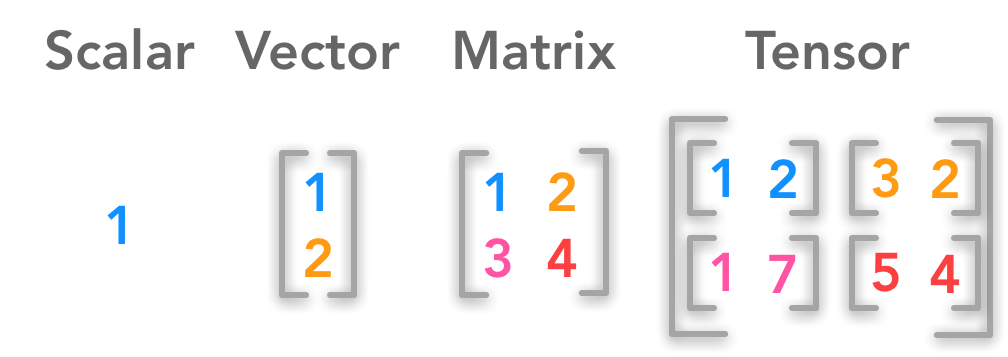

#### 1.1.1 Scalar
1. It's data type is tensor.

In [ ]:
scalar = torch.tensor(7)
scalar

tensor(7)

2. Scalar is a single number which has no dimension.

In [ ]:
scalar.ndim

0

3. Turn tensor back as regular Python integer.

In [ ]:
scalar.item()

7

#### 1.1.2 Vector

*   Has magniture
*   Has direction



In [ ]:
# Vector
vector = torch.tensor([7, 7])
vector

tensor([7, 7])

1. One dimentional array

In [ ]:
vector.ndim

1

2. Two elements.

In [ ]:
vector.shape

torch.Size([2])

#### 1.1.3 Matrix

In [ ]:
MATRIX = torch.tensor([[7, 8],
                      [9, 10]])
MATRIX

tensor([[ 7,  8],
        [ 9, 10]])

In [ ]:
MATRIX.ndim

2

In [ ]:
MATRIX[1]

tensor([ 9, 10])

In [ ]:
MATRIX.shape

torch.Size([2, 2])

#### 1.1.4 Tensor

In [ ]:
TENSOR = torch.tensor([[[1, 2, 3],
                       [4, 5, 6],
                       [7, 8, 9]]])
TENSOR

tensor([[[1, 2, 3],
         [4, 5, 6],
         [7, 8, 9]]])

In [ ]:
TENSOR.ndim

3

In [ ]:
TENSOR.shape

torch.Size([1, 3, 3])

### 1.2 Creating Random Tensors

**Why random tensors?**

Random tensors are important because the way many neural networks learn is that they start with tensors full of random numbers and then adjust those random numbers to better represent the data

`Start with random numbers -> Look at data -> Update random numbers -> Look at data -> Update random numbers`

Torch random tensors = https://docs.pytorch.org/docs/main/generated/torch.rand.html

In [ ]:
# Create a random tensors of size (3, 4)
random_tensor = torch.rand(3, 4)
random_tensor

tensor([[0.6956, 0.7968, 0.4687, 0.7256],
        [0.7937, 0.6847, 0.0418, 0.2781],
        [0.3445, 0.4264, 0.4525, 0.0398]])

In [ ]:
random_tensor.ndim

2

In [ ]:
# To represent an image tensor: 224px x 224px x 3 color channel
random_image_size_tensor = torch.rand(size=(224, 224, 3))
random_image_size_tensor.shape, random_image_size_tensor.ndim

(torch.Size([224, 224, 3]), 3)

### 1.3 Creating Zeros and Ones Tensors

For some reasons, we need zero tensors sometimes, e.g. to tell model to ignore all the number in here.

In [ ]:
zero = torch.zeros(size=(3, 4))
zero

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

In [ ]:
zero * random_tensor

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

In [ ]:
ones = torch.ones(size=(3, 4))
ones

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])

In [ ]:
ones.dtype

torch.float32

### 1.4 Creating a range of tensors and tensors-like

In [ ]:
# Use torch.arange()
one_to_ten = torch.arange(start=1, end=10, step=2)
one_to_ten

tensor([1, 3, 5, 7, 9])

In [ ]:
# Creating tensors like
# To create tensors with the same shape
ten_zeros = torch.zeros_like(one_to_ten)
ten_zeros

tensor([0, 0, 0, 0, 0])

## 2. Tensor dataypes

**Precison in Computing**

> How much detail in which the quantity is expressed.

Even though the data type is set to none, the default data type in PyTorch is float 32.

In [ ]:
# Float 32 tensor
float_32_tensor = torch.tensor([3.0, 6.0, 9.0],
                               dtype=None)
float_32_tensor.dtype

torch.float32

In [ ]:
# Float 16 tensor
float_16_tensor = torch.tensor([3.0, 6.0, 9.0],
                               dtype=torch.float16)
float_16_tensor.dtype

torch.float16

In [ ]:
# Default setting of PyTorch
float_32_tensor = torch.tensor([3.0, 6.0, 9.0],
                               dtype=None,   # What datatype is the tensor (e.g. float32 or float16)
                               device=None,  # What device is your tensor on
                               requires_grad=False)  # Whether or not to track gradients with this tensors operation
float_32_tensor.dtype

torch.float32

**Note:** Tensor datatypes is one of the 3 big errors you'll run into with PyTorch & deep learning:

1. Tensors not right data type
2. Tensors not right shape
3. Tensors not on the right device



In [ ]:
# Convert from float32 to float16
float_16_tensor = float_32_tensor.type(torch.float16)
float_16_tensor

tensor([3., 6., 9.], dtype=torch.float16)

### 3. Getting information from tensors

1. `tensor.dtyoe`

2. `tensor.shape`

3. `tensor.device`

In [ ]:
# Create a tensor
some_tensor = torch.rand(3, 4)
some_tensor

tensor([[0.0790, 0.8156, 0.5186, 0.7158],
        [0.7579, 0.9693, 0.1623, 0.6784],
        [0.9551, 0.7576, 0.7642, 0.1109]])

In [ ]:
# Find out the details of a tensor
print(some_tensor)
print()

print(f"Datatype of tensor: {some_tensor.dtype}")
print(f"Shape of tensor: {some_tensor.shape}")
print(f"Device tensor is on: {some_tensor.device}")

tensor([[0.0790, 0.8156, 0.5186, 0.7158],
        [0.7579, 0.9693, 0.1623, 0.6784],
        [0.9551, 0.7576, 0.7642, 0.1109]])

Datatype of tensor: torch.float32
Shape of tensor: torch.Size([3, 4])
Device tensor is on: cpu


### 4. Manipulating Tensors

Tensor Operations include:
* Addition
* Subtraction
* Multiplication (element-wise)
* Devision
* Matrix multiplication

#### 4.1 Tensor Operations by Python operators

In [ ]:
# Create a tensor & add 10 to it
tensor = torch.tensor([1, 2, 3])
tensor + 10

tensor([11, 12, 13])

In [ ]:
# Multiple tensor by 10
tensor * 10

tensor([10, 20, 30])

In [ ]:
# Subtract tensor by 10
tensor - 10

tensor([-9, -8, -7])

#### 4.2 Tensor Operations by PyTorch in-built functions

In [ ]:
# Try out PyTorch in-built functions
torch.mul(tensor, 10)

tensor([10, 20, 30])

In [ ]:
torch.add(tensor, 10)

tensor([11, 12, 13])

#### 4.3 Matrix Multiplication

Two main ways of performing multiplication in neural networks and deep learning:

1. Element-wise multiplication
2. Matrix multiplication (dot product. '@')

More information on multipliying matrices: https://www.mathsisfun.com/algebra/matrix-multiplying.html

Dot product animation: http://matrixmultiplication.xyz/

In [ ]:
# Element wise multiplication
print(tensor, "*", tensor)
print(f"Equals: {tensor * tensor}")

tensor([1, 2, 3]) * tensor([1, 2, 3])
Equals: tensor([1, 4, 9])


In [ ]:
# Matrix multiplication (Recommended)
torch.matmul(tensor, tensor)

tensor(14)

In [ ]:
# Matrix multiplication
tensor @ tensor

tensor(14)

Two main rules in performing matrix multiplication:

1. The **inner dimensions** must match:
* `(3, 2) @ (3, 2)` won't work
* `(2, 3) @ (3, 2)` will work
* `(3, 2) @ (2, 3)` will work

2. The resulting matrix has the shape of the **outer dimensions.**
* `(2, 3) @ (3, 2)`-> `(2, 2)`
* `(4, 2) @ (2, 4)`-> `(2, 2)`

In [ ]:
torch.matmul(torch.rand(2, 3), torch.rand(3, 2))

tensor([[0.5267, 0.5250],
        [0.6320, 0.3825]])

In [ ]:
# One of the most common errors in deep learning: Shape Errors
torch.matmul(torch.rand(2, 3), torch.rand(2, 3))

RuntimeError: mat1 and mat2 shapes cannot be multiplied (2x3 and 2x3)

**Transpose** Matrix to Solve Shape Errors


In [ ]:
tensor_A = torch.tensor([[1, 2],
                         [3, 4],
                         [5, 6]])

tensor_B = torch.tensor([[7, 10],
                         [8, 11],
                         [9, 12]])

torch.matmul(tensor_A, tensor_B)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (3x2 and 3x2)

The inner dimensions of matrix A and matrix B does not match.

In [ ]:
print(f"{tensor_A.shape} @ {tensor_B.shape}")

torch.Size([3, 2]) @ torch.Size([3, 2])


To fix this, manipulate the shape of one of the tensors using **Transpose**

A **transpose** switches the axes or dimensions of a given tensor.

In [ ]:
tensor_B.T.shape

torch.Size([2, 3])

In [ ]:
torch.matmul(tensor_A, tensor_B.T)

tensor([[ 27,  30,  33],
        [ 61,  68,  75],
        [ 95, 106, 117]])

### 5. PyTorch Reproducibility
https://www.geeksforgeeks.org/deep-learning/reproducibility-in-pytorch/

Trying to take the random out of random

In short, how a neural network learns:
1. `start with random numbers`
2. `tensor operation`
3. `update random numbers to try and make them better representations of the data`
4. `again`
5. `again`
6. `again`

To reduce the randomness in neural networks and PyTorch comes the concept of a **random seed**.

In [ ]:
import torch

# Create two random tensors
random_tensor_A = torch.rand(3, 4)
random_tensor_B = torch.rand(3, 4)

print(random_tensor_A)
print(random_tensor_B)
print(random_tensor_A == random_tensor_B)

tensor([[0.5292, 0.7507, 0.4288, 0.3711],
        [0.4661, 0.8192, 0.2718, 0.8770],
        [0.7039, 0.8959, 0.2532, 0.7702]])
tensor([[0.5763, 0.8012, 0.9620, 0.1035],
        [0.7185, 0.2766, 0.4426, 0.7860],
        [0.3170, 0.6818, 0.3173, 0.9178]])
tensor([[False, False, False, False],
        [False, False, False, False],
        [False, False, False, False]])


In [ ]:
# Let's make some random but reproducible tensors
import torch

# Set the random seed
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
random_tensor_C = torch.rand(3, 4)

torch.manual_seed(RANDOM_SEED)
random_tensor_D = torch.rand(3, 4)

print(random_tensor_C)
print(random_tensor_D)
print(random_tensor_C == random_tensor_D)

tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])
tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])
tensor([[True, True, True, True],
        [True, True, True, True],
        [True, True, True, True]])


### 6. Running tensors and PyTorch objects on GPUs

#### 6.1 Getting a GPU
1. Use Google Colab
2. Use your own GPU
3. Use cloud computing - GCP, AWS, Azure, ...

For 2 & 3 PyTorch + GPU drivers (CUDA) takes a little bit of setting up:

https://pytorch.org/get-started/locally/

In [ ]:
# Check for GPU access with PyTorch
import torch
torch.cuda.is_available()

False

For PyTorch, it is best practice to setup device agnostic code:

https://pytorch.org/get-started/locally/

In [ ]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
# Count number of devices
torch.cuda.device_count()

0

#### 6.2 Putting tensors (and models) on GPU

Using a GPU results in faster computation

In [ ]:
# Create a tensor (default on the CPU)
tensor = torch.tensor([1, 2, 3])

# Tensor not on GPU
print(tensor, tensor.device)

tensor([1, 2, 3]) cpu


In [ ]:
# Move tensor to GPU (if available)
tensor_on_gpu = tensor.to(device)
tensor_on_gpu

tensor([1, 2, 3])

#### 6.3 Moving tensors back to the CPU

Numpy only works on CPU, but

Tensors working on both CPU or GPU

In [ ]:
# If tensor is on GPU, can't transform it to Numpy
tensor_on_gpu.numpy()

In [ ]:
# To fix the GPU tensor with Numpy issue, we can first set it to the CPU
tensor_back_on_cpu = tensor_on_gpu.cpu().numpy
tensor_back_on_cpu